In [1]:
import numpy as np
import pandas as pd
original_matrix = pd.read_csv("prs_partialR_matrix_260225_loinccode_qc.csv")
original_matrix = original_matrix.set_index("trait")
original_matrix = original_matrix.apply(pd.to_numeric, errors='coerce') 
rank_matrix = pd.read_csv("prs_partialR_matrix_260225_loinccode_rankmatrix.csv")
rank_matrix = rank_matrix.set_index("trait")
target_rank_matrix = pd.read_csv("prs_partialR_matrix_260225_loinccode_selfrankmatrix.csv")
target_rank_matrix = target_rank_matrix.set_index("trait")
metainfo = pd.read_csv("../../measurement_preprocess/pgs_metadata_260225.csv")
metainfo = metainfo.drop_duplicates(subset="PGS_ID", keep="first").set_index("PGS_ID")

## Across All Available Candidate PGS

### Histogram of the Best Performing PGS 

10835-7 0.6602897532606341


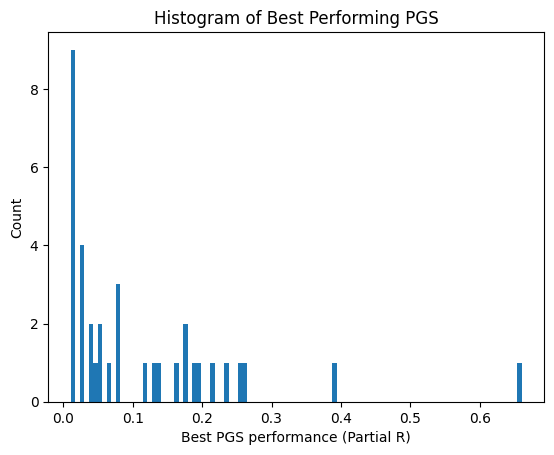

In [34]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(max(matrix.loc[trait]))
    if max(matrix.loc[trait]) > 0.4:
        print(trait, max(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance (Partial R)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing PGS")
plt.show()

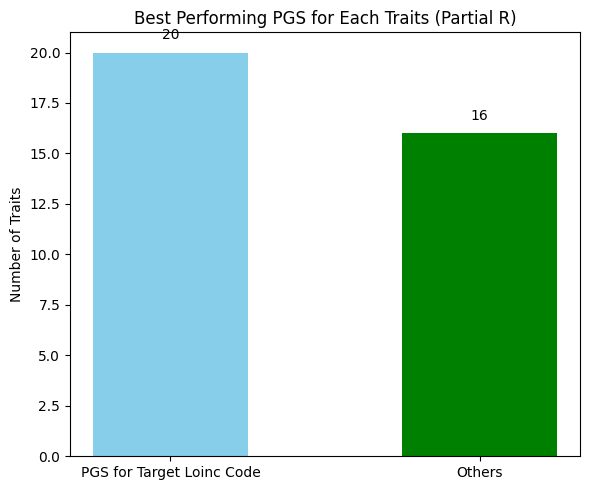

In [29]:
self_pgs_count = 0
same_chap_count = 0
others = 0
for trait in rank_matrix.index:

    best_pgs = rank_matrix.loc[trait].iloc[0]

    if trait in best_pgs.split("__")[0].split("+"):
        self_pgs_count += 1
        continue
    
    else:
        others += 1

counts = [self_pgs_count, others]
labels = ["PGS for Target Loinc Code", "Others"]
x = [0, 3] 

plt.figure(figsize=(6,5))
plt.bar(x, counts, color=["skyblue", "green"], width=1.5)
plt.xticks(x, labels)
plt.ylabel("Number of Traits")
plt.title("Best Performing PGS for Each Traits (Partial R)")
for i, count in enumerate(counts):
    plt.text(x[i], count + 0.5, str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

3084-1
4544-3
788-0
789-8


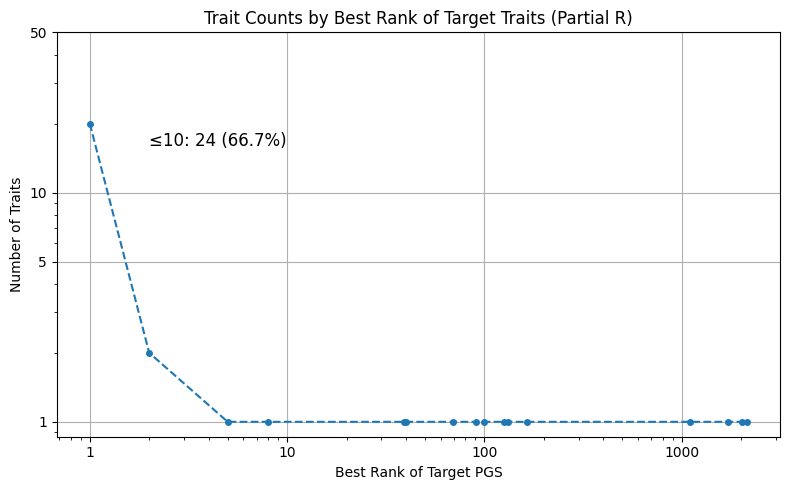

In [30]:
from collections import Counter

best_self_pgs_rank = []
for trait in rank_matrix.index:

    for idx, m in enumerate(rank_matrix.loc[trait]):
        
        if trait in m.split("__")[0].split("+"):
            best_self_pgs_rank.append(idx + 1)
            if idx > 1000:
                print(trait)
            break


rank_counts = Counter(best_self_pgs_rank)
ranks = sorted(rank_counts.keys())
counts = [rank_counts[r] for r in ranks]

total_traits = len(best_self_pgs_rank)
num_top10 = sum(
    count for r, count in rank_counts.items() if r <= 10
)
ratio = num_top10 / total_traits

plt.figure(figsize=(8,5))
plt.plot(ranks, counts, '--', marker='o', markersize=4)

plt.text(
    2, max(counts)*0.8,
    f"≤10: {num_top10} ({ratio:.1%})",
    fontsize=12
)

plt.xlabel("Best Rank of Target PGS")
plt.ylabel("Number of Traits")
plt.title("Trait Counts by Best Rank of Target Traits (Partial R)")
plt.xscale('log')
plt.yscale('log')
plt.xticks([1, 10, 100, 1000], ["1", "10", "100", "1000"])
plt.yticks([1, 5, 10, 50], ["1", "5", "10", "50"])
plt.grid(0.6)
plt.tight_layout()
plt.show()

### Histogram of the Worse Performing PGS 

10835-7 -0.4220272845622846
18262-6 -0.1086874455107009
1869-7 -0.159174653822736
1884-6 -0.1657909765656718
2085-9 -0.01054220590464
2093-3 -0.0106360382127122
2243-4 -0.0477819273458704
2571-8 -0.0104177764701077
26474-7 -0.0279441849801244
26478-8 -0.1574444248824037
26485-3 -0.0771109469806924
26511-6 -0.1598485435336645
28539-5 -0.070088482513566
29463-7 -0.2769219500685692
2986-8 -0.075845637705506
30522-7 -0.0469049762625411
3084-1 -0.0248216654829516
39156-5 -0.0217804217468553
43396-1 -0.1344455323625979
4544-3 -0.0102716253725113
4548-4 -0.0130397616104228
62292-8 -0.0895228642210749
704-7 -0.0254453091996296
706-2 -0.0437609051037347
711-2 -0.0172857545269569
713-8 -0.0351876087174065
718-7 -0.0099701761149558
742-7 -0.0248284668788146
751-8 -0.0246396510695138
777-3 -0.0117581017625642
786-4 -0.0103862483261006
788-0 -0.0103615185490564
789-8 -0.012234316897309
8462-4 -0.1174383331064333
8480-6 -0.0450568845623843
8867-4 -0.0568299900922403


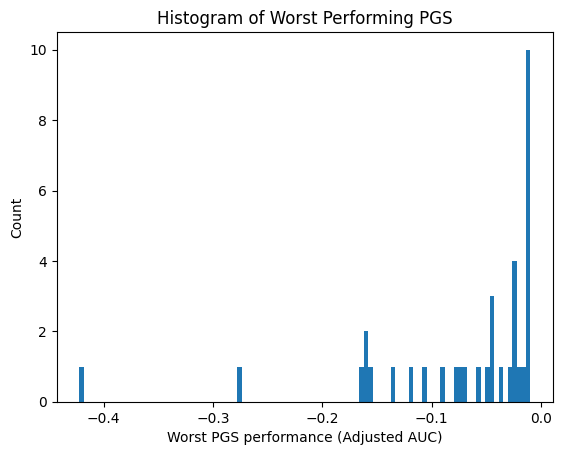

In [33]:
matrix = original_matrix.copy()
max_list = []
for trait in matrix.index:
    max_list.append(min(matrix.loc[trait]))
    if min(matrix.loc[trait]) < 0.2:
        print(trait, min(matrix.loc[trait]))
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing PGS")
plt.show()

### Histogram of the PRS Performing Range

10835-7 0.42436793877686985


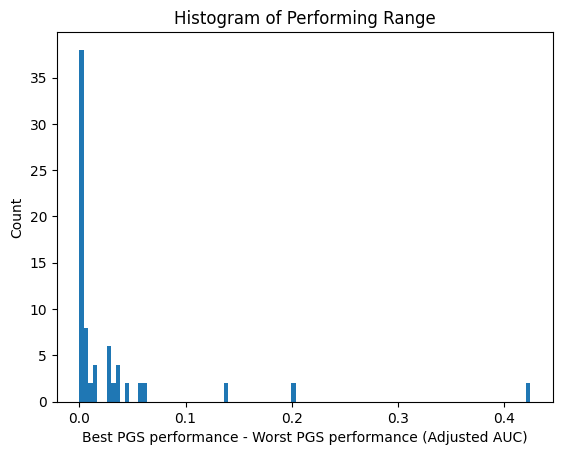

In [15]:
matrix = original_matrix.copy()
for trait in matrix.index:
    temp = max(matrix.loc[trait]) - min(matrix.loc[trait])
    max_list.append(temp)
    if temp > 0.4:
        print(trait, temp)
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Worst PGS performance (Adjusted AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

In [16]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.nanmin(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.4]
print("Traits with performance range bigget than 0.4: ", large_diff_traits)

Traits with performance range bigget than 0.4:  ['10835-7']


### Histogram of Range Between Median and the Best

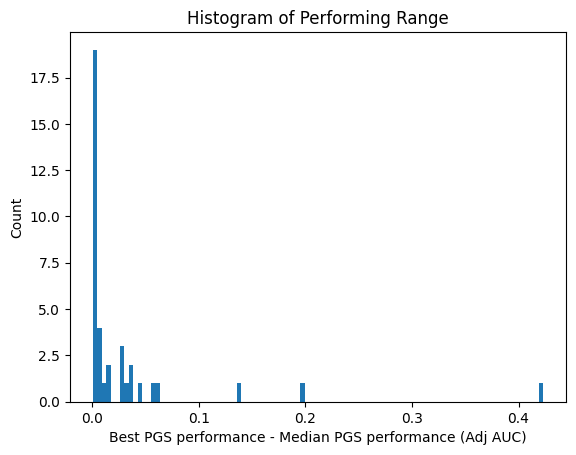

In [17]:
matrix = original_matrix.copy()
max_list = [max(matrix.loc[trait]) - np.median(matrix.loc[trait]) for trait in matrix.index]
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance - Median PGS performance (Adj AUC)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show() 

In [18]:
diff_dict = {}

for trait in matrix.index:
    values = matrix.loc[trait].values.astype(float)
    diff = np.nanmax(values) - np.median(values)
    diff_dict[trait] = diff

large_diff_traits = [t for t, d in diff_dict.items() if d > 0.3]
print("Traits with performance range bigget than 0.3: ", large_diff_traits)

Traits with performance range bigget than 0.3:  ['10835-7']


## Across Target PGS Only

### Histogram of Target PGS Counts

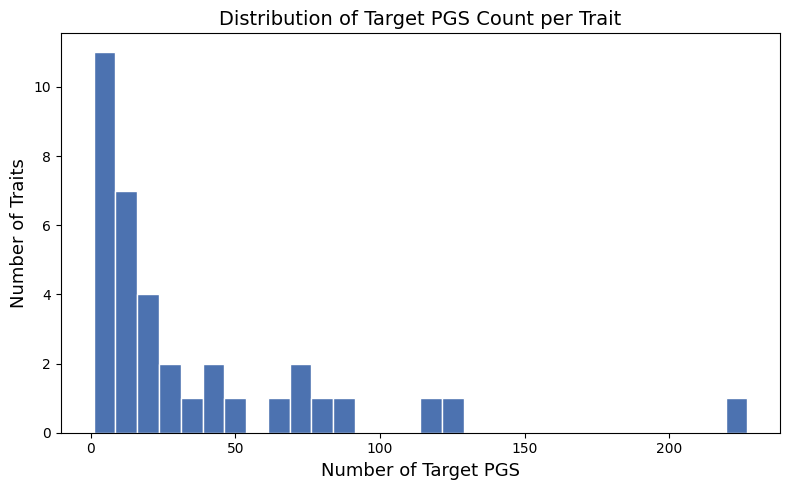

count     36.000000
mean      35.888889
std       46.447991
min        1.000000
25%        8.000000
50%       17.000000
75%       46.250000
max      227.000000
dtype: float64


In [2]:
import matplotlib.pyplot as plt

n_target_pgs = target_rank_matrix.notna().sum(axis=1)

plt.figure(figsize=(8, 5))
plt.hist(n_target_pgs, bins=30, edgecolor="white", color="#4C72B0")
plt.xlabel("Number of Target PGS", fontsize=13)
plt.ylabel("Number of Traits", fontsize=13)
plt.title("Distribution of Target PGS Count per Trait", fontsize=14)
plt.tight_layout()
plt.show()

print(n_target_pgs.describe())

In [ ]:
print(n_target_pgs)

### Histogram of the Best PGS

10835-7 0.6602897532606341
29463-7 0.3906721804548163


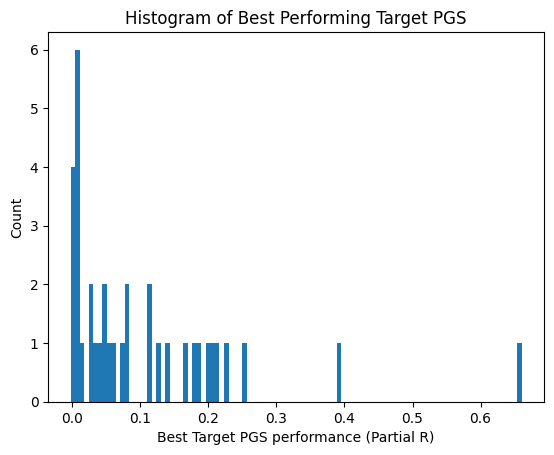

In [3]:
import matplotlib.pyplot as plt
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    best_auc = max(matrix.loc[trait, self_cols])
    max_list.append(best_auc)
    if best_auc > 0.3:
        print(trait, best_auc)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best Target PGS performance (Partial R)")
plt.ylabel("Count")
plt.title("Histogram of Best Performing Target PGS")
plt.show()

### Histogram of the Worst PGS

10835-7 -0.4220272845622846
29463-7 -0.2769219500685692


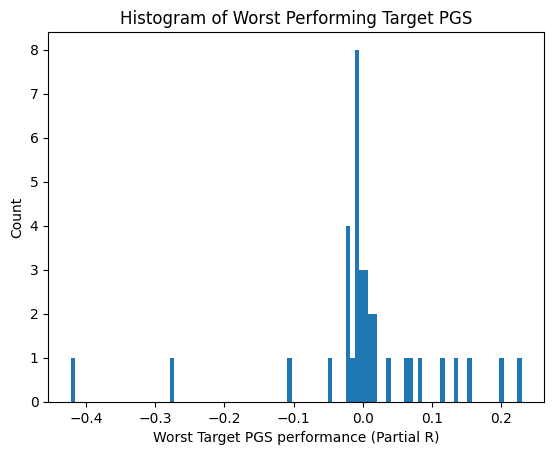

In [4]:
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    worst_auc = min(matrix.loc[trait, self_cols])
    max_list.append(worst_auc)
    if worst_auc < -0.2:
        print(trait, worst_auc)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Worst Target PGS performance (Partial R)")
plt.ylabel("Count")
plt.title("Histogram of Worst Performing Target PGS")
plt.show()

### Histogram of the Range

10835-7 1.0823170378229188
29463-7 0.6675941305233855


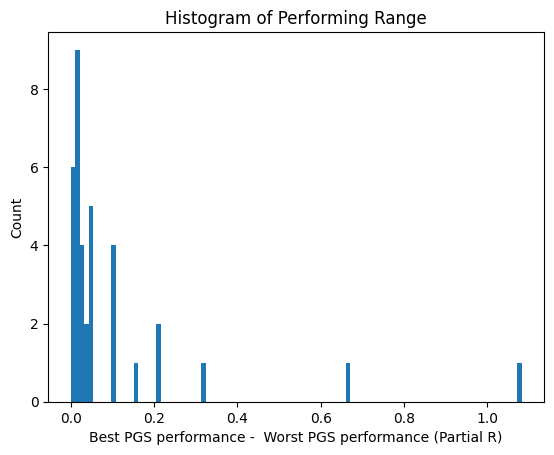

In [5]:
matrix = original_matrix.copy()
max_list = []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    auc_range = max(matrix.loc[trait, self_cols]) - min(matrix.loc[trait, self_cols])
    max_list.append(auc_range)
    if auc_range > 0.5:
        print(trait, auc_range)
plt.figure()
plt.hist(max_list, bins=100)
plt.xlabel("Best PGS performance -  Worst PGS performance (Partial R)")
plt.ylabel("Count")
plt.title("Histogram of Performing Range")
plt.show()

### Correlation: Number of Variants - Performance

In [11]:
def add_significance(ax, x1, x2, y, p):
    h = y * 0.05
    ax.plot([x1, x1, x2, x2], [y, y+h, y+h, y], lw=1.5)
    
    if p < 0.001:
        text = "***"
    elif p < 0.01:
        text = "**"
    elif p < 0.05:
        text = "*"
    else:
        text = "ns"
    
    ax.text((x1+x2)/2, y+h, text, ha='center', va='bottom')

In [12]:
from scipy.stats import gaussian_kde

def half_violin(ax, data, pos, color, width=0.3, side='right', alpha=0.75, log_scale=False):
    data = np.array(data)
    
    if log_scale:
        data_fit = np.log10(data[data > 0])  # KDE 在 log 空间
    else:
        data_fit = data
    
    kde = gaussian_kde(data_fit, bw_method=0.3)
    y_fit = np.linspace(data_fit.min(), data_fit.max(), 300)
    x = kde(y_fit)
    x = x / x.max() * width
    
    y_plot = 10 ** y_fit if log_scale else y_fit  # 转回原始尺度
    
    if side == 'right':
        ax.fill_betweenx(y_plot, pos, pos + x, color=color, alpha=alpha, linewidth=0)
        ax.plot(pos + x, y_plot, color=color, linewidth=0.8)
    else:
        ax.fill_betweenx(y_plot, pos - x, pos, color=color, alpha=alpha, linewidth=0)
        ax.plot(pos - x, y_plot, color=color, linewidth=0.8)

In [65]:
num_variant_best = []
num_variant_median = []
num_variant_worst = []

for trait in rank_matrix.index:

    pgs_list = []
    num_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        pgs_list.append(temp_id)

        num_var = metainfo.loc[temp_id]["num_variant"]
        num_list.append(num_var)

    if len(num_list) < 3:
        continue
    num_array = np.array(num_list)
    best = num_array[0]
    worst = num_array[-1]
    median = num_array[len(num_array) // 2]

    num_variant_best.append(best)
    num_variant_median.append(median)
    num_variant_worst.append(worst)

Global p: 0.4911774073663564


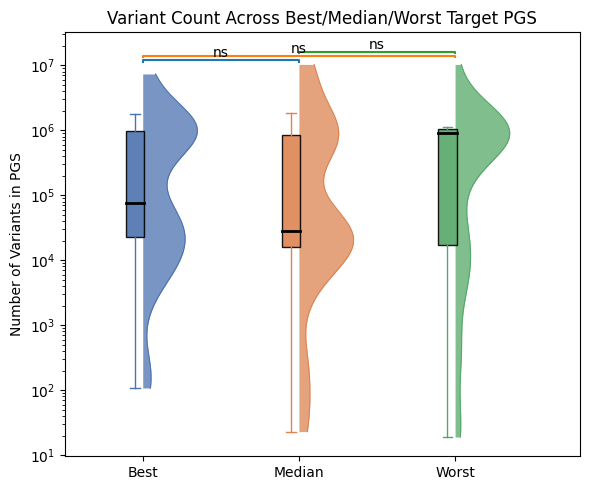

In [66]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color, label in zip(positions, data, colors, labels):
    # half violin plot
    half_violin(ax, d, pos, color, width=0.35, log_scale=True) 
    
    # half box plot
    bp = ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
                    showfliers=False, patch_artist=True,
                    medianprops=dict(color='black', linewidth=2),
                    boxprops=dict(facecolor=color, alpha=0.9),
                    whiskerprops=dict(color=color),
                    capprops=dict(color=color))
ax.set_yscale("log")
ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Number of Variants in PGS")
ax.set_title("Variant Count Across Best/Median/Worst Target PGS")

y_max = max([max(d) for d in data])
add_significance(ax, 1, 2, y_max * 1.1, p1)
add_significance(ax, 1, 3, y_max * 1.3, p2)
add_significance(ax, 2, 3, y_max * 1.5, p3)

plt.tight_layout()
plt.show()

### Correlation: Date Release - Performance

In [67]:
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        release_date = pd.to_datetime(metainfo.loc[temp_id]["date_release"])
        days_diff = (today - release_date).days

        days_list.append(days_diff)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

Global p: 0.3001314173511432


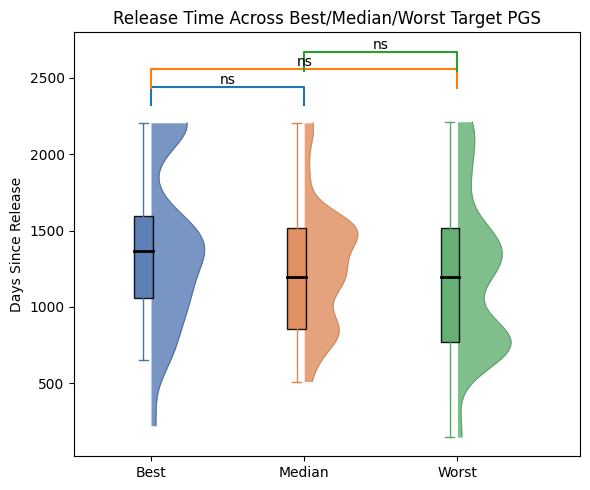

In [68]:
import matplotlib.pyplot as plt

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]  # 这里存的是 days
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Days Since Release")
ax.set_title("Release Time Across Best/Median/Worst Target PGS")

y_max = max([max(d) for d in data])
add_significance(ax, 1, 2, y_max * 1.05, p1)
add_significance(ax, 1, 3, y_max * 1.10, p2)
add_significance(ax, 2, 3, y_max * 1.15, p3)

plt.tight_layout()
plt.show()

### Correlation: Reported Performance - Performance

#### Incremental R2

In [13]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if "Incremental R2" not in metric:
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan

In [14]:
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [15]:
print(num_variant_worst)

[0.1127, 0.009000000000000001, 0.0115, 0.0044, 0.0073, 0.0146]


Global p: 0.05165153864020272


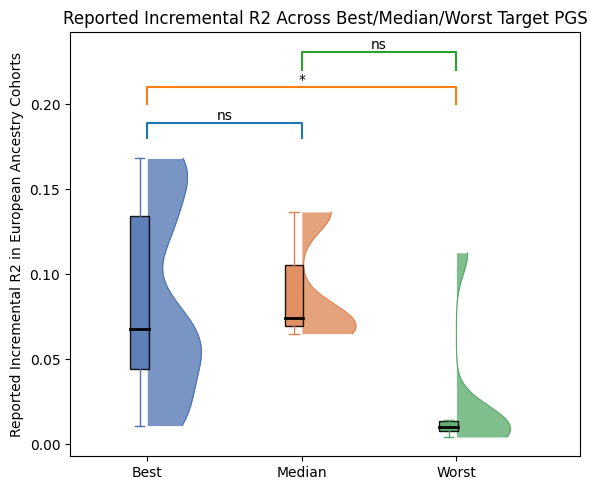

In [16]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Reported Incremental R2 in European Ancestry Cohorts")
ax.set_title("Reported Incremental R2 Across Best/Median/Worst Target PGS")

add_significance(ax, 1, 2, 0.18, p1)
add_significance(ax, 1, 3, 0.20, p2)
add_significance(ax, 2, 3, 0.22, p3)

plt.tight_layout()
plt.show()

#### Beta

In [17]:
from scipy.stats import norm

def beta_to_auc(beta):
    return norm.cdf(beta / np.sqrt(2))

def or_to_auc(OR):
    beta = np.log(OR)
    return norm.cdf(beta / np.sqrt(2))

def partial_r_to_auc(r):
    d = 2*r / np.sqrt(1 - r**2)
    return norm.cdf(d / np.sqrt(2))

def perpare_report_performance(eval_estimate: list, eval_ancestry: list, eval_metrics: list) -> float:
    result = []
    for idx, estimate in enumerate(eval_estimate):
        if not eval_ancestry[idx] == 'European':
            continue
        metric = eval_metrics[idx]
        if "Beta" not in metric:
            continue
        result.append(estimate)
    if len(result) > 0:
        return float(np.mean(result))
    else:
        return np.nan
    
import ast
matrix = original_matrix.copy()
today = pd.Timestamp.today()

days_best = []
days_median = []
days_worst = []

for trait in rank_matrix.index:

    days_list = []

    for m in rank_matrix.loc[trait]:

        if trait not in m.split("__")[0].split("+"):
            continue

        temp_id = m.split("__")[1]

        eval_estimate = ast.literal_eval(metainfo.loc[temp_id]["eval_estimate"])
        eval_ancestry = ast.literal_eval(metainfo.loc[temp_id]["eval_ancestry"])
        eval_metrics = ast.literal_eval(metainfo.loc[temp_id]["eval_metrics"])
        num_var = perpare_report_performance(eval_estimate, eval_ancestry, eval_metrics)

        days_list.append(num_var)

    if len(days_list) < 3:
        continue

    days_array = np.array(days_list)

    days_best.append(days_array[0])
    days_median.append(days_array[len(days_array)//2])
    days_worst.append(days_array[-1])

In [18]:
print(num_variant_worst)

[0.1127, 0.009000000000000001, 0.0115, 0.0044, 0.0073, 0.0146]


Global p: 0.7882656173497408


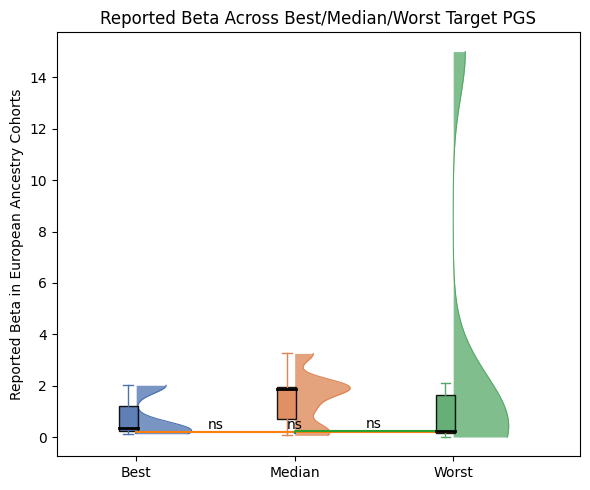

In [19]:
import matplotlib.pyplot as plt
from scipy.stats import kruskal, mannwhitneyu

num_variant_best = [x for x in days_best if pd.notna(x)]
num_variant_median = [x for x in days_median if pd.notna(x)]
num_variant_worst = [x for x in days_worst if pd.notna(x)]

# hypothesis testing
# overall test
stat, p_global = kruskal(
    num_variant_best,
    num_variant_median,
    num_variant_worst
)

print("Global p:", p_global)

# pairwise
p1 = mannwhitneyu(num_variant_best, num_variant_median).pvalue
p2 = mannwhitneyu(num_variant_best, num_variant_worst).pvalue
p3 = mannwhitneyu(num_variant_median, num_variant_worst).pvalue

colors = ['#4C72B0', '#DD8452', '#55A868']
labels = ["Best", "Median", "Worst"]
data = [num_variant_best, num_variant_median, num_variant_worst]
positions = [1, 2, 3]

fig, ax = plt.subplots(figsize=(6, 5))

for pos, d, color in zip(positions, data, colors):
    half_violin(ax, d, pos, color, width=0.35, log_scale=False)
    ax.boxplot(d, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.set_xticks(positions)
ax.set_xticklabels(labels)
ax.set_xlim(0.5, 3.8)
ax.set_ylabel("Reported Beta in European Ancestry Cohorts")
ax.set_title("Reported Beta Across Best/Median/Worst Target PGS")

add_significance(ax, 1, 2, 0.18, p1)
add_significance(ax, 1, 3, 0.20, p2)
add_significance(ax, 2, 3, 0.22, p3)

plt.tight_layout()
plt.show()

### Target PGS performance distribution

9 traits with > 50 target PGS: ['18262-6', '2085-9', '2093-3', '2571-8', '29463-7', '39156-5', '718-7', '8462-4', '8480-6']


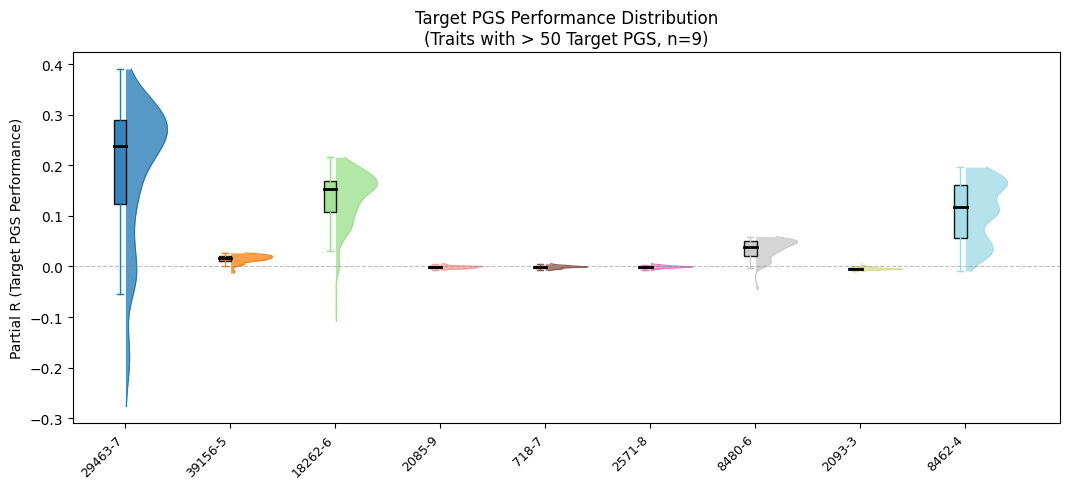


Trait               N   Median     Best    Worst
29463-7           227   0.2387   0.3907  -0.2769
39156-5           125   0.0169   0.0269  -0.0131
18262-6           117   0.1526   0.2157  -0.1087
2085-9             88  -0.0015   0.0060  -0.0072
718-7              83  -0.0009   0.0053  -0.0081
2571-8             71  -0.0009   0.0063  -0.0078
8480-6             71   0.0395   0.0591  -0.0451
2093-3             66  -0.0050   0.0068  -0.0099
8462-4             53   0.1169   0.1966  -0.0094


In [26]:
import matplotlib.pyplot as plt
import numpy as np
from scipy.stats import gaussian_kde

# 筛选 target PGS 数量 > 200 的 trait
n_target_pgs = target_rank_matrix.notna().sum(axis=1)
selected_traits = n_target_pgs[n_target_pgs > 50].index.tolist()
print(f"{len(selected_traits)} traits with > 50 target PGS: {selected_traits}")

# 收集每个 trait 的 performance 值
trait_perf = {}
for trait in selected_traits:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    vals = original_matrix.loc[trait, self_cols].dropna().values.astype(float)
    trait_perf[trait] = vals

# ---- 画图 ----
fig, ax = plt.subplots(figsize=(max(8, len(sorted_traits) * 1.2), 5))

colors = plt.cm.tab20(np.linspace(0, 1, len(sorted_traits)))

for i, (trait, color) in enumerate(zip(sorted_traits, colors)):
    vals = trait_perf[trait]
    pos = i + 1

    # half violin（向右展开）
    kde = gaussian_kde(vals, bw_method=0.3)
    y = np.linspace(vals.min(), vals.max(), 300)
    x = kde(y)
    x = x / x.max() * 0.4
    ax.fill_betweenx(y, pos, pos + x, color=color, alpha=0.75, linewidth=0)
    ax.plot(pos + x, y, color=color, linewidth=0.8)

    # box
    ax.boxplot(vals, positions=[pos - 0.05], widths=0.12,
               showfliers=False, patch_artist=True,
               medianprops=dict(color='black', linewidth=2),
               boxprops=dict(facecolor=color, alpha=0.9),
               whiskerprops=dict(color=color),
               capprops=dict(color=color))

ax.axhline(0, color='gray', linewidth=0.8, linestyle='--', alpha=0.5)
ax.set_xticks(range(1, len(sorted_traits) + 1))
ax.set_xticklabels(sorted_traits, rotation=45, ha='right', fontsize=9)
ax.set_xlim(0.5, len(sorted_traits) + 0.9)
ax.set_ylabel("Partial R (Target PGS Performance)")
ax.set_title(f"Target PGS Performance Distribution\n(Traits with > 50 Target PGS, n={len(sorted_traits)})")

plt.tight_layout()
plt.show()

# 打印汇总
print(f"\n{'Trait':<15} {'N':>5} {'Median':>8} {'Best':>8} {'Worst':>8}")
for trait in sorted_traits:
    v = trait_perf[trait]
    print(f"{trait:<15} {len(v):>5} {np.median(v):>8.4f} {v.max():>8.4f} {v.min():>8.4f}")


### Best PGS Performance Vs Target PGS Number

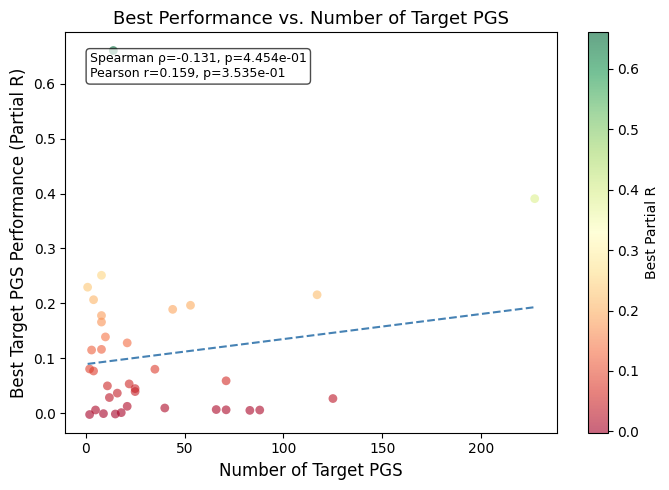

In [23]:
import matplotlib.pyplot as plt
import numpy as np

n_target_pgs = target_rank_matrix.notna().sum(axis=1)

x_list, y_list, trait_list = [], [], []
for trait in target_rank_matrix.index:
    self_cols = target_rank_matrix.loc[trait].dropna().tolist()
    if not self_cols:
        continue
    best = original_matrix.loc[trait, self_cols].max()
    x_list.append(n_target_pgs[trait])
    y_list.append(best)
    trait_list.append(trait)

x = np.array(x_list)
y = np.array(y_list)

# 相关系数
from scipy.stats import spearmanr, pearsonr
rho, p_sp = spearmanr(x, y)
r, p_pe = pearsonr(x, y)

fig, ax = plt.subplots(figsize=(7, 5))
sc = ax.scatter(x, y, alpha=0.6, s=40, c=y, cmap='RdYlGn', edgecolors='none')
plt.colorbar(sc, ax=ax, label="Best Partial R")

# 趋势线
z = np.polyfit(x, y, 1)
xline = np.linspace(x.min(), x.max(), 200)
ax.plot(xline, np.polyval(z, xline), color='steelblue', linewidth=1.5, linestyle='--')

ax.set_xlabel("Number of Target PGS", fontsize=12)
ax.set_ylabel("Best Target PGS Performance (Partial R)", fontsize=12)
ax.set_title("Best Performance vs. Number of Target PGS", fontsize=13)
ax.text(0.05, 0.95, f"Spearman ρ={rho:.3f}, p={p_sp:.3e}\nPearson r={r:.3f}, p={p_pe:.3e}",
        transform=ax.transAxes, va='top', fontsize=9,
        bbox=dict(boxstyle='round', facecolor='white', alpha=0.7))

plt.tight_layout()
plt.show()
